<a href="https://colab.research.google.com/github/barandincoguz/DNN_Project/blob/main/notebooks/colab_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DNN Universal Approximation — Colab

**Öncesinde:** Runtime > Change runtime type > **GPU (T4)**

---

## Çalıştırma Sırası

| Adım | Bölüm | Ne yapar |
|------|-------|----------|
| 1 | **Kurulum** (4 hücre) | Repo, pip, GPU, W&B — her oturumda çalıştır |
| 2 | **EDA** (4 hücre) | Veri analizi — ilk seferde veya merak edince |
| 3 | **Config** (1 hücre) | Mevcut ayarları gör, deney için override et |
| 4 | **Eğitim + Submission** (1 hücre) | Eğit → grafikleri kaydet → submission.csv üret |
| 5 | **Sonuçlar** (3 hücre) | Grafikleri gör, submission önizle ve indir |
| 6 | **Push** (1 hücre) | Sonuçları GitHub'a gönder |
| 7 | **Optuna** (1 hücre) | Hyperparameter arama (opsiyonel) |

> **Temel akış:** 1 → 3 → 4 → 5 → 6

---
## 1. Kurulum

In [2]:
# ── 1.1 Repo sync ────────────────────────────────────────────────
# Öncesinde: Sol panel > Anahtar ikonu (Secrets) > GITHUB_TOKEN ekle
import os, sys
from google.colab import userdata

TOKEN = userdata.get('GITHUB_TOKEN')
REPO  = f'https://{TOKEN}@github.com/barandincoguz/DNN_Project.git'
DIR   = '/content/DNN_Project'

if not os.path.exists(DIR):
    !git clone {REPO} {DIR}
else:
    !cd {DIR} && git fetch https://{TOKEN}@github.com/barandincoguz/DNN_Project.git main && git reset --hard FETCH_HEAD

os.chdir(DIR)
if DIR not in sys.path:
    sys.path.insert(0, DIR)

print('Çalışma dizini:', os.getcwd())

From https://github.com/barandincoguz/DNN_Project
 * branch            main       -> FETCH_HEAD
HEAD is now at 0c2b491 Update README: add Open in Colab badge, clean up structure
Çalışma dizini: /content/DNN_Project


In [3]:
# ── 1.2 Bağımlılıklar ────────────────────────────────────────────
!pip install -q -r requirements.txt
print('Kurulum tamamlandı.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.8 MB/s eta 0:00:00
Kurulum tamamlandı.


In [4]:
# ── 1.3 Ortam kontrolü ───────────────────────────────────────────
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Yok'

print(f'Python   : {sys.version.split()[0]}')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {device}')
print(f'GPU      : {gpu_name}')

if device == 'cpu':
    print('\n[UYARI] GPU bulunamadı! Runtime > Change runtime type > GPU seç.')

Python   : 3.12.13
PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4


In [5]:
# ── 1.4 W&B login ────────────────────────────────────────────────
# Öncesinde: Sol panel > Anahtar ikonu (Secrets) > WANDB_API_KEY ekle
import wandb

wandb.login(key=userdata.get('WANDB_API_KEY'))
print('W&B login başarılı.')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kaankaya928 (kaankaya928-ted-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login başarılı.


---
## 2. EDA (Detaylı Veri Analizi)

In [ ]:
# ── 2.1 Genel bakış ──────────────────────────────────────────────
import pandas as pd
import numpy as np

train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print('=== TRAIN ===')
print(f'Shape: {train.shape}')
print(f'\nİlk 5 satır:')
display(train.head())

print('\n=== Eksik değerler ===')
display(train.isnull().sum().to_frame('train_null').join(
    test.isnull().sum().to_frame('test_null')))

print('\n=== İstatistikler ===')
display(train.describe())

In [ ]:
# ── 2.2 Feature dağılımları ──────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

features = ['f1', 'f2', 'f3', 'f4', 'f5']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(train[col].dropna(), bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{col} (skew={train[col].skew():.2f})')
    axes[i].set_xlabel(col)

axes[5].hist(train['target'], bins=40, edgecolor='black', alpha=0.7, color='tomato')
axes[5].set_title(f'target (skew={train["target"].skew():.2f})')

plt.suptitle('Feature Dağılımları', fontsize=14)
plt.tight_layout()
plt.show()
print('[NOT] f5 = tuzak feature, modelde kullanılmayacak.')

In [ ]:
# ── 2.3 Korelasyon ve feature-target ilişkileri ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = train[['f1','f2','f3','f4','f5','target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True)
axes[0].set_title('Korelasyon Matrisi')

axes[1].axis('off')
fig2, axes2 = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(['f1','f2','f3','f4']):
    axes2[i].scatter(train[col], train['target'], alpha=0.2, s=8, color='steelblue')
    axes2[i].set_xlabel(col)
    axes2[i].set_ylabel('target' if i == 0 else '')
    axes2[i].set_title(f'{col} vs target')

plt.suptitle('Feature-Target İlişkileri', fontsize=13)
plt.tight_layout()
plt.show()

print('Kullanılacak featureların target ile korelasyonu:')
print(corr['target'][['f1','f2','f3','f4']].to_string())

In [ ]:
# ── 2.4 f3 log1p dönüşümü etkisi ─────────────────────────────────
f3 = train['f3'].clip(lower=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(f3, bins=40, edgecolor='black', alpha=0.7)
axes[0].set_title(f'f3 orijinal (skew={f3.skew():.2f})')

f3_log = np.log1p(f3)
axes[1].hist(f3_log, bins=40, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title(f'f3 log1p sonrası (skew={f3_log.skew():.2f})')

plt.tight_layout()
plt.show()

---
## 3. Config

In [6]:
# ── 3.1 Config kontrol / override ────────────────────────────────
# Bu hücrede değiştirdiğin ayarlar Bölüm 4'teki eğitime yansır
# çünkü aynı Python kernel'da çalışır.
import src.config as cfg

print('=== MEVCUT CONFIG ===')
print(f'DEVICE    : {cfg.DEVICE}')
print(f'HIDDEN    : {cfg.HIDDEN_LAYERS}')
print(f'LR        : {cfg.LEARNING_RATE}')
print(f'DROPOUT   : {cfg.DROPOUT_RATE}')
print(f'EPOCHS    : {cfg.EPOCHS}')
print(f'PATIENCE  : {cfg.PATIENCE}')
print(f'LOSS      : {cfg.LOSS_FN}')
print(f'BATCH_SIZE: {cfg.BATCH_SIZE}')
print(f'WANDB     : {cfg.WANDB_ENABLED}')

# Deney için override et (yorum satırını aç):
# cfg.HIDDEN_LAYERS = [256, 512, 256, 128]
# cfg.LEARNING_RATE = 5e-4
# cfg.DROPOUT_RATE  = 0.2
# cfg.EPOCHS = 300

=== MEVCUT CONFIG ===
DEVICE    : cuda
HIDDEN    : [128, 256, 128, 64]
LR        : 0.001
DROPOUT   : 0.15
EPOCHS    : 500
PATIENCE  : 25
LOSS      : MSE
BATCH_SIZE: 64
WANDB     : True


---
## 4. Eğitim + Submission

> Tek hücre: eğitir → grafikleri kaydeder → submission.csv üretir.

In [ ]:
# ── 4.1 Eğit + submission üret ───────────────────────────────────
# Colab'da kernel cache'i temizlemek için modülleri sırayla reload et.
# ÖNEMLİ: src.config reload edilmiyor — edilirse override'lar sıfırlanır!
import importlib
import src.dataset, src.model, src.evaluate, src.train, src.predict

importlib.reload(src.dataset)   # FEATURES_TO_USE, IMPUTE_K, N_FOLDS, SEED
importlib.reload(src.model)     # DNN mimarisi
importlib.reload(src.evaluate)  # PLOT_DIR
importlib.reload(src.train)     # optimizer, scheduler, loss, epochs, patience
importlib.reload(src.predict)   # submission path

from src.train import train_all_folds
from src.evaluate import plot_training_curves
from src.predict import generate_submission
import pandas as pd

# Eğitim (5-fold CV, W&B'ye loglanır)
fold_maes, test_preds, histories = train_all_folds()

# Grafikleri kaydet
plot_training_curves(histories, save=True)

# Submission üret
test_df = pd.read_csv('data/test.csv')
generate_submission(test_preds, test_df)

---
## 5. Sonuçlar

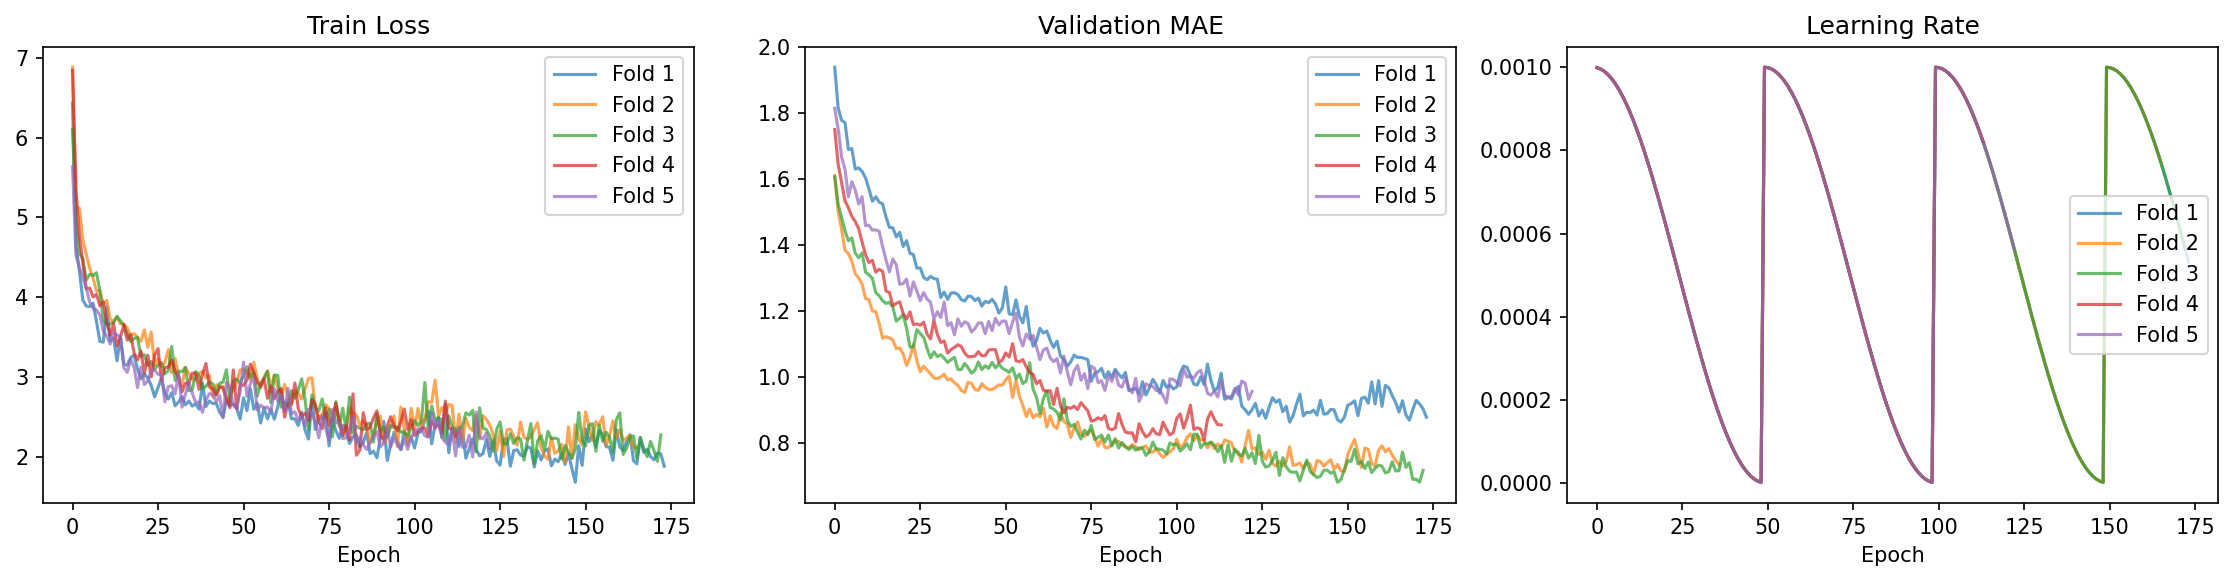

In [8]:
# ── 5.1 Training curves ──────────────────────────────────────────
from PIL import Image
display(Image.open('outputs/plots/training_curves.png'))

In [9]:
# ── 5.2 Submission önizleme ──────────────────────────────────────
sub = pd.read_csv('outputs/submission.csv')
print(f'Shape : {sub.shape}')
print(f'Target: mean={sub.target.mean():.4f}, std={sub.target.std():.4f}')
display(sub.head(10))

Shape : (400, 2)
Target: mean=0.2622, std=2.4858


,id,target
0,1601,-0.718295
1,1602,-2.528854
2,1603,1.896554
3,1604,-1.228170
4,1605,3.620512
5,1606,0.329890
6,1607,-0.218716
7,1608,-0.879899
8,1609,-4.647614
9,1610,-0.377389


In [10]:
# ── 5.3 Submission indir ─────────────────────────────────────────
from google.colab import files
files.download('outputs/submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 6. GitHub'a Push

In [11]:
# ── 6.1 Sonuçları push et ────────────────────────────────────────
import os
from google.colab import userdata

github_token = userdata.get('GITHUB_TOKEN')
commit_msg   = input('Commit mesajı (örn: mae=0.1234 deeper-arch): ')

os.chdir('/content/DNN_Project')

!git config user.email "colab@dnn"
!git config user.name "Colab"
!git add outputs/submission.csv outputs/plots/ Reports/

# Değişiklik varsa commit et, sonra her zaman push
!git diff --cached --quiet || git commit -m "{commit_msg}"
!git push https://{github_token}@github.com/barandincoguz/DNN_Project.git main

Commit mesajı (örn: mae=0.1234 deeper-arch): deneme
[main 18908a3] deneme
 2 files changed, 401 insertions(+)
 create mode 100644 outputs/plots/training_curves.png
 create mode 100644 outputs/submission.csv
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (6/6), 205.24 KiB | 17.10 MiB/s, done.
Total 6 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/barandincoguz/DNN_Project.git
   0c2b491..18908a3  main -> main


---
## 7. Optuna Tuning (Opsiyonel)

In [ ]:
# ── 7.1 Hyperparameter arama ─────────────────────────────────────
# Uzun sürer (n_trials * fold sayısı kadar eğitim)
!python -m src.tune